# Stock Price Time Series Analysis

## Overview

This project analyzes historical stock prices using Python and Pandas. The analysis focuses on understanding price trends, resampling time-series data, calculating moving averages, and comparing trading volumes between two companies.

### Objectives

- Download historical stock data using the `yfinance` library.
- Work with dates as a time-series index.
- Plot stock closing prices over time.
- Resample data into weekly and monthly intervals.
- Calculate 20-day and 200-day moving averages.
- Compare trading volumes between two companies.

### Technologies Used

- Python
- Pandas
- yfinance
- Matplotlib
- Jupyter Notebook

# Table of Contents

1. Import Libraries
2. Download Historical Stock Data
3. Explore the Dataset
4. Closing Price Analysis
5. Time Series Resampling
6. Moving Average Analysis
7. Trading Volume Analysis
8. Daily Returns Analysis
9. Cumulative Returns Analysis
10. Volatility Analysis
11. Correlation Analysis
12. Annual Performance Summary
13. Conclusion

## 1. Import Required Libraries

The following libraries are used throughout this project:

- **Pandas** for data manipulation and time-series analysis.
- **Matplotlib** for creating visualizations.
- **yfinance** for downloading historical stock data directly from Yahoo Finance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# Display all columns when viewing dataframe
pd.set_option("display.max_columns", None)

# Increase display width
pd.set_option("display.width", 1000)

# Using clean plotting style
plt.style.use("ggplot")

## 2. Download Historical Stock Data

Historical stock price data is downloaded using the **yfinance** library, which retrieves financial data directly from Yahoo Finance.

For this project, we will analyze the stock prices of:

- **Apple Inc. (AAPL)**
- **Microsoft Corporation (MSFT)**

These companies were chosen because they are among the largest technology companies in the world and have extensive historical market data available.

In [3]:
import os
import yfinance as yf

cache_dir = os.path.join(os.getcwd(), "yf_cache")
os.makedirs(cache_dir, exist_ok=True)

yf.set_tz_cache_location(cache_dir)

In [4]:
# Define the ticker symbols
tickers = ["AAPL", "MSFT"]

# Download Apple stock data
aapl = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)

# Flatten the MultiIndex columns
aapl.columns = aapl.columns.get_level_values(0)

# Download Microsoft stock data
msft = yf.download(
    "MSFT",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)

# Flatten the MultiIndex columns
msft.columns = msft.columns.get_level_values(0)

In [5]:
print("Apple Dataset")
display(aapl.head())

print("\nMicrosoft Dataset")
display(msft.head())

Apple Dataset


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861862,72.466345,71.642704,72.211064,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200



Microsoft Dataset


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,151.829514,151.933494,149.664848,150.090217,22622100
2020-01-03,149.938980,151.196193,149.409630,149.655410,21116200
2020-01-06,150.326553,150.392729,147.944465,148.483276,20813700
2020-01-07,148.955933,150.931547,148.710167,150.600711,21634100
2020-01-08,151.328552,151.999702,149.305671,150.232034,27746500


In [6]:
print(f"Apple Dataset Shape: {aapl.shape}")
print(f"Microsoft Dataset Shape: {msft.shape}")

Apple Dataset Shape: (1258, 5)
Microsoft Dataset Shape: (1258, 5)


In [7]:
aapl.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1258 non-null   float64
 1   High    1258 non-null   float64
 2   Low     1258 non-null   float64
 3   Open    1258 non-null   float64
 4   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [8]:
print("Apple")
print(aapl.isnull().sum())

print("\nMicrosoft")
print(msft.isnull().sum())

Apple
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Microsoft
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## 3. Exploring the Time Series

Before performing any analysis, we inspect the structure of the time-series data.

The datasets use a **DatetimeIndex**, which allows Pandas to efficiently perform date-based operations such as filtering, resampling, and calculating rolling statistics.

In [9]:
print(type(aapl.index))
print(type(msft.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [10]:
print("Apple")
print("Start Date:", aapl.index.min())
print("End Date:", aapl.index.max())

print("\nMicrosoft")
print("Start Date:", msft.index.min())
print("End Date:", msft.index.max())

Apple
Start Date: 2020-01-02 00:00:00
End Date: 2024-12-31 00:00:00

Microsoft
Start Date: 2020-01-02 00:00:00
End Date: 2024-12-31 00:00:00


## 4. Closing Price Analysis

The closing price represents the final trading price of a stock at the end of the trading day.

It is widely used in financial analysis because it reflects the market's final valuation of a stock for that day.

The following visualization compares the daily closing prices of Apple and Microsoft over the selected time period.

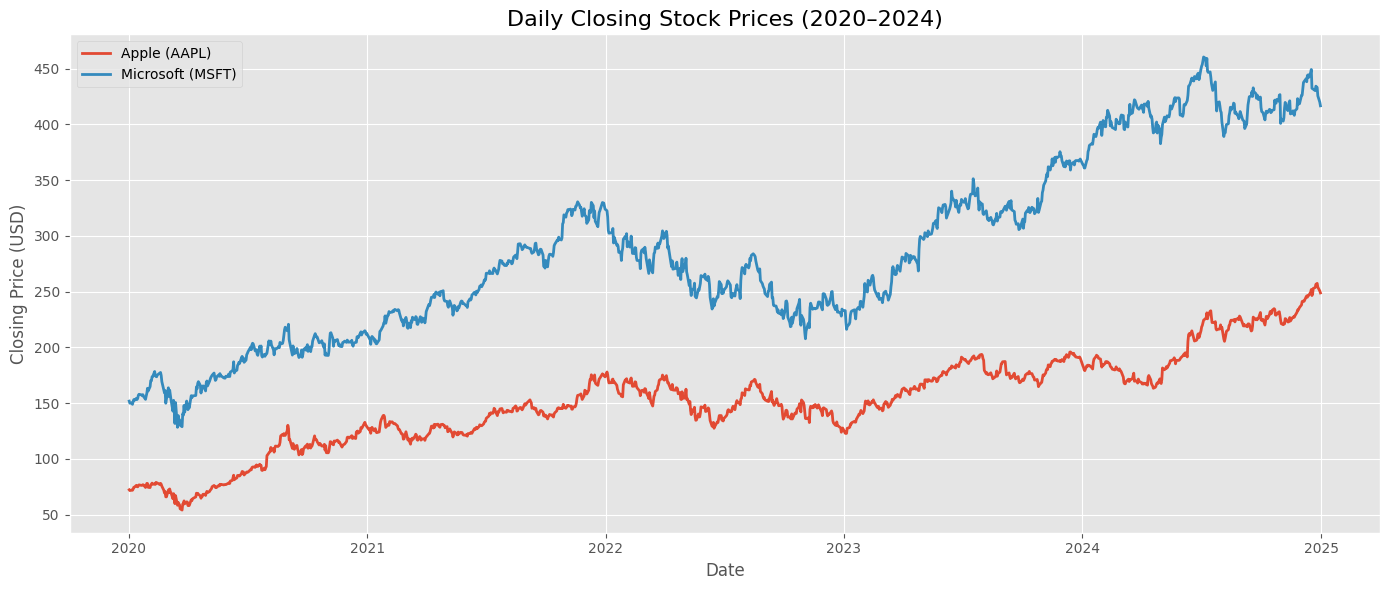

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(aapl.index, aapl["Close"], label="Apple (AAPL)", linewidth=2)
plt.plot(msft.index, msft["Close"], label="Microsoft (MSFT)", linewidth=2)

plt.title("Daily Closing Stock Prices (2020–2024)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/closing_prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

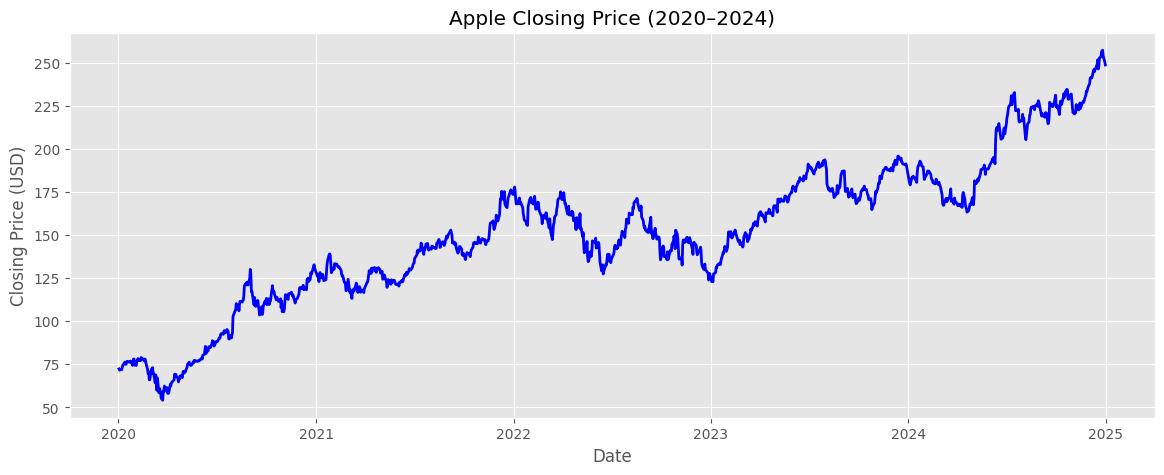

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(aapl.index, aapl["Close"], color="blue", linewidth=2)

plt.title("Apple Closing Price (2020–2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)

plt.show()

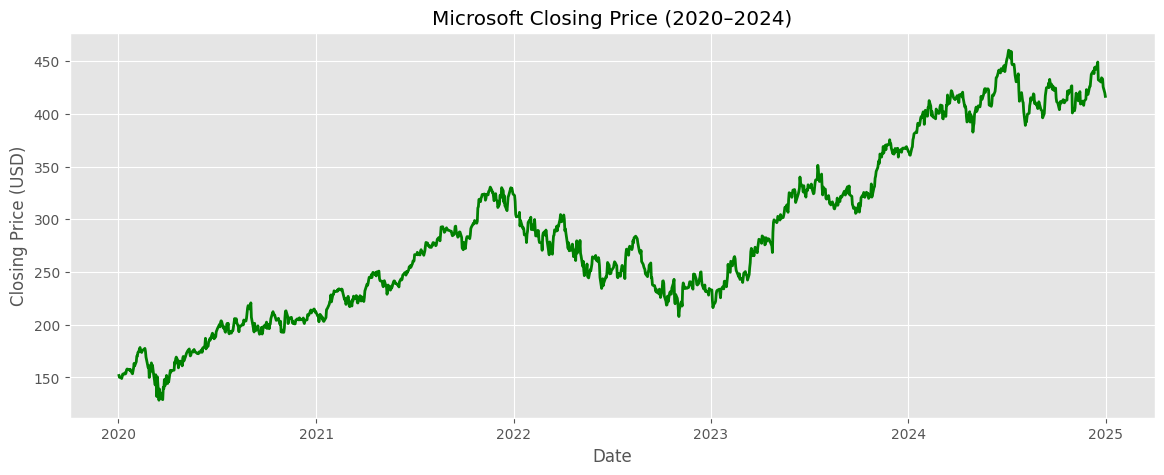

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(msft.index, msft["Close"], color="green", linewidth=2)

plt.title("Microsoft Closing Price (2020–2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True)

plt.show()

### Observations

- Both Apple and Microsoft show an overall upward trend during the selected time period.
- Short-term fluctuations are visible, reflecting normal market volatility.
- Significant price movements can be observed during major market events, particularly around 2020.
- Microsoft appears to have experienced steadier long-term growth, while Apple shows larger fluctuations during certain periods.

## 5. Time Series Resampling

Stock prices are recorded for every trading day. However, analysts often examine data over longer periods such as weeks or months to identify broader trends and reduce short-term fluctuations.

In this section, we resample the daily stock data into weekly and monthly intervals.

In [14]:
# Weekly stock data (last trading day of each week)
aapl_weekly = aapl.resample("W").last()
msft_weekly = msft.resample("W").last()

In [15]:
aapl_weekly.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-05,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-12,74.737373,75.300927,74.236446,74.802403,140644800
2020-01-19,76.760353,76.762756,75.862047,76.167901,137816400
2020-01-26,76.659210,77.868184,76.468951,77.126425,146537600
2020-02-02,74.539909,77.711662,74.246094,77.290206,199588400


In [16]:
# Monthly stock data (last trading day of each month)
aapl_monthly = aapl.resample("ME").last()
msft_monthly = msft.resample("ME").last()

In [17]:
aapl_monthly.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-31,74.539909,77.711662,74.246094,77.290206,199588400
2020-02-29,65.990059,67.209151,61.888616,62.103468,426510000
2020-03-31,61.386494,63.366002,60.833681,61.702735,197002000
2020-04-30,70.924339,71.100566,69.608695,69.997351,183064000
2020-05-31,76.959587,77.736588,76.603763,77.276681,153532400


In [18]:
print("Daily observations:", len(aapl))
print("Weekly observations:", len(aapl_weekly))
print("Monthly observations:", len(aapl_monthly))

Daily observations: 1258
Weekly observations: 262
Monthly observations: 60


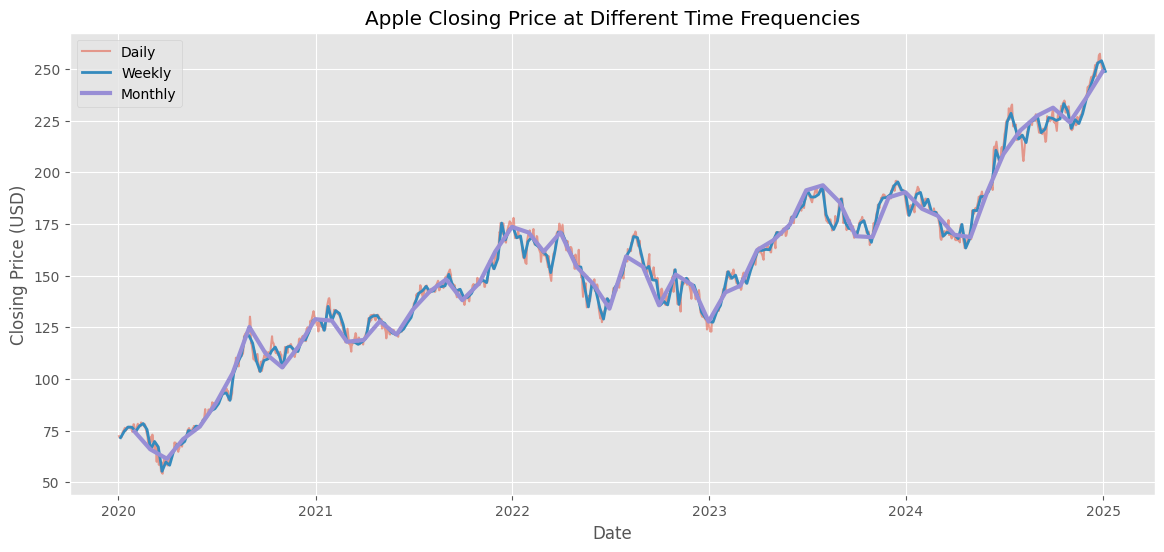

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(aapl["Close"], label="Daily", alpha=0.5)
plt.plot(aapl_weekly["Close"], label="Weekly", linewidth=2)
plt.plot(aapl_monthly["Close"], label="Monthly", linewidth=3)

plt.title("Apple Closing Price at Different Time Frequencies")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

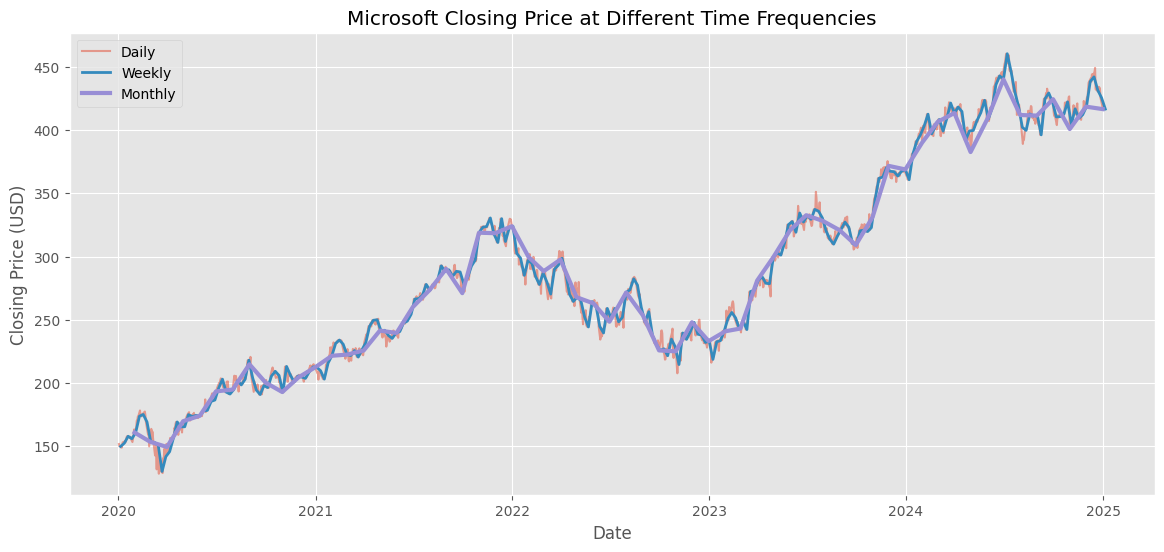

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(msft["Close"], label="Daily", alpha=0.5)
plt.plot(msft_weekly["Close"], label="Weekly", linewidth=2)
plt.plot(msft_monthly["Close"], label="Monthly", linewidth=3)

plt.title("Microsoft Closing Price at Different Time Frequencies")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Monthly Average Volume
aapl_monthly_volume = aapl["Volume"].resample("ME").mean()
msft_monthly_volume = msft["Volume"].resample("ME").mean()

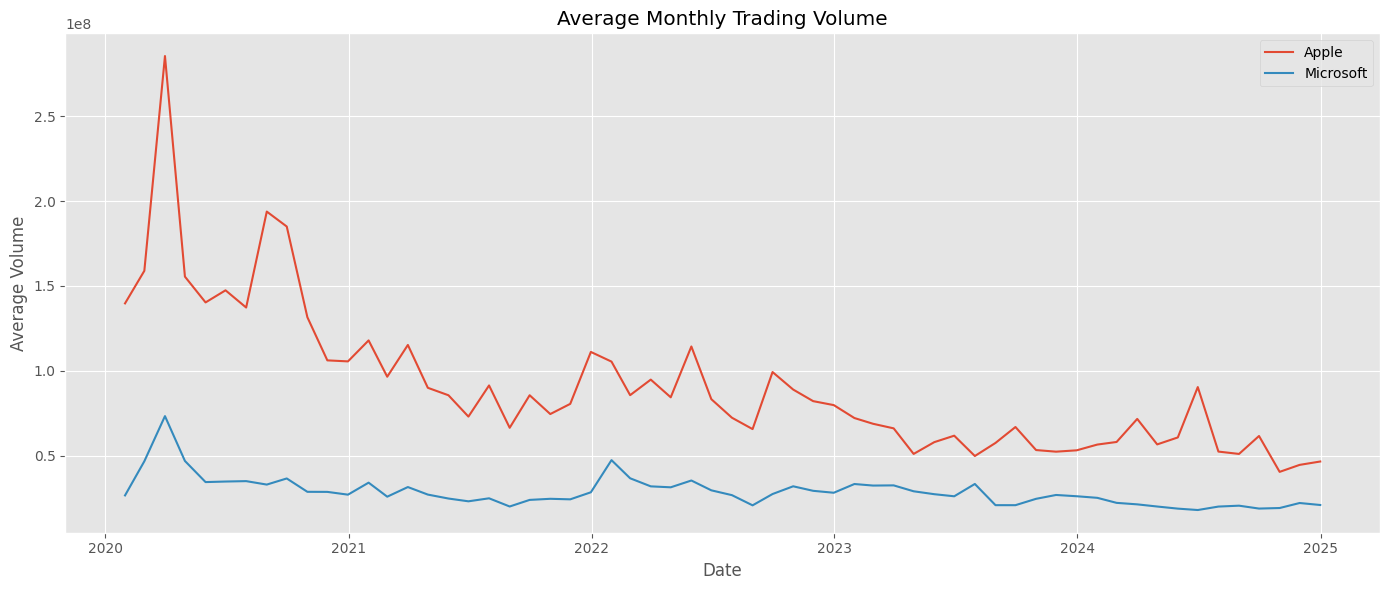

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(aapl_monthly_volume, label="Apple")
plt.plot(msft_monthly_volume, label="Microsoft")

plt.title("Average Monthly Trading Volume")
plt.xlabel("Date")
plt.ylabel("Average Volume")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/trading_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- Weekly and monthly resampling smooth out short-term market fluctuations.
- Monthly data provides a clearer view of long-term price trends.
- Daily data captures every trading session, making it useful for detailed analysis but noisier.
- Average monthly trading volume helps identify periods of increased or decreased market activity.

## 6. Moving Average Analysis

Daily stock prices often fluctuate due to short-term market activity. Moving averages smooth these fluctuations by calculating the average closing price over a fixed number of trading days.

This analysis computes:

- **20-day Moving Average (MA20)** to highlight short-term trends.
- **200-day Moving Average (MA200)** to highlight long-term trends.

These indicators are commonly used by investors to identify market trends and potential changes in momentum.

In [23]:
aapl["MA20"] = aapl["Close"].rolling(window=20).mean()
aapl["MA200"] = aapl["Close"].rolling(window=200).mean()

In [24]:
msft["MA20"] = msft["Close"].rolling(window=20).mean()
msft["MA200"] = msft["Close"].rolling(window=200).mean()

In [25]:
aapl[["Close", "MA20", "MA200"]].head(25)

Price,Close,MA20,MA200
Date,,,
2020-01-02,72.333885,NaN,NaN
2020-01-03,71.630646,NaN,NaN
2020-01-06,72.201408,NaN,NaN
2020-01-07,71.861862,NaN,NaN
2020-01-08,73.017845,NaN,NaN
2020-01-09,74.568802,NaN,NaN
2020-01-10,74.737373,NaN,NaN
2020-01-13,76.334091,NaN,NaN
2020-01-14,75.303337,NaN,NaN


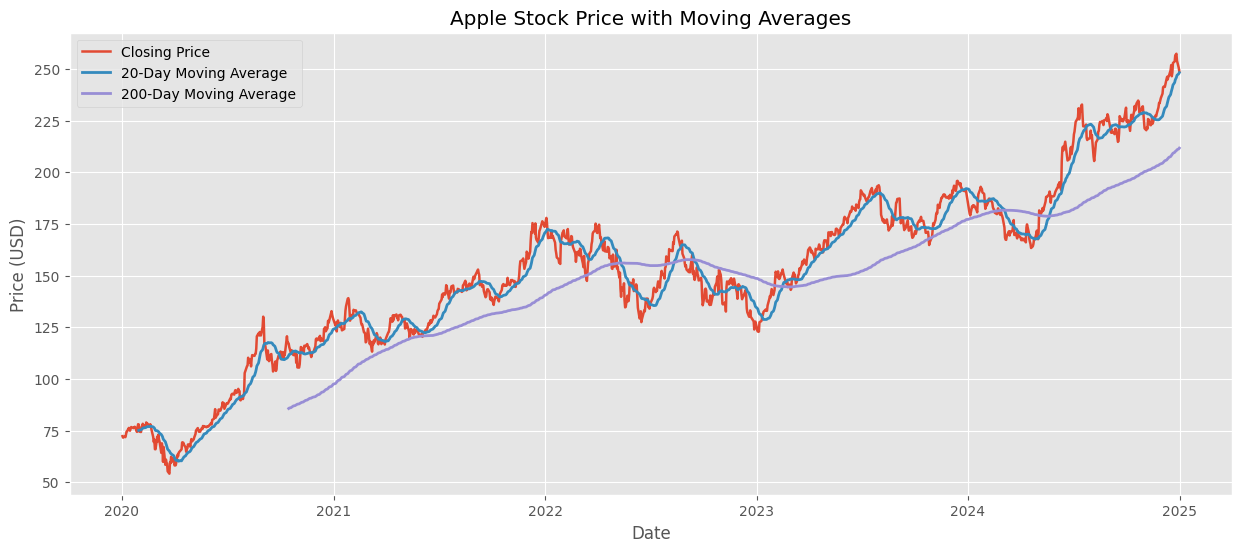

In [26]:
plt.figure(figsize=(15,6))

plt.plot(aapl["Close"], label="Closing Price", linewidth=1.8)

plt.plot(aapl["MA20"],
         label="20-Day Moving Average",
         linewidth=2)

plt.plot(aapl["MA200"],
         label="200-Day Moving Average",
         linewidth=2)

plt.title("Apple Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

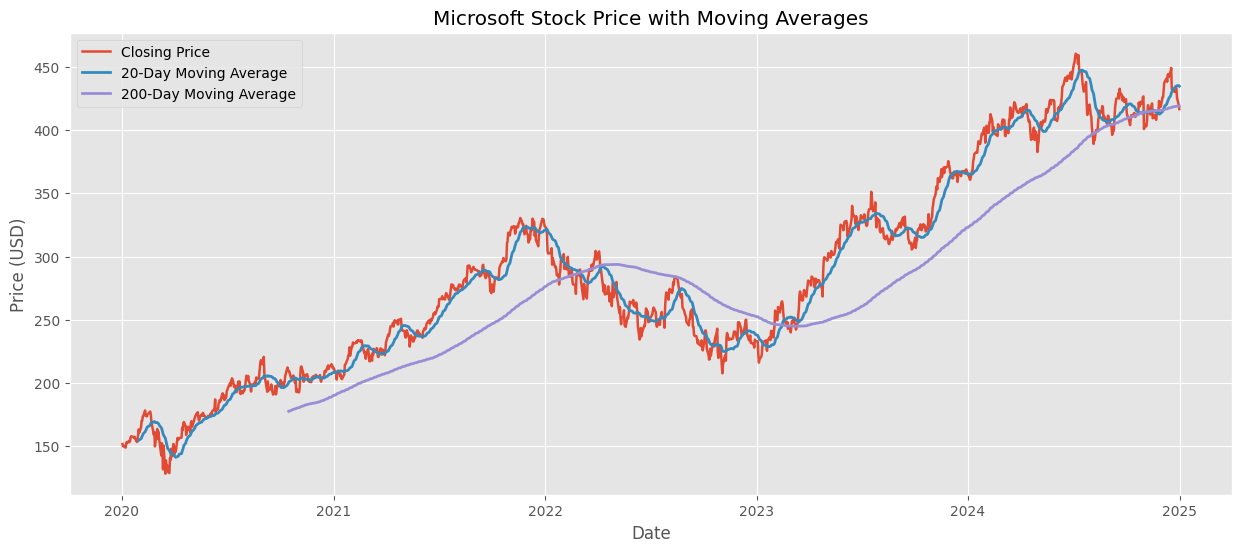

In [27]:
plt.figure(figsize=(15,6))

plt.plot(msft["Close"], label="Closing Price", linewidth=1.8)

plt.plot(msft["MA20"],
         label="20-Day Moving Average",
         linewidth=2)

plt.plot(msft["MA200"],
         label="200-Day Moving Average",
         linewidth=2)

plt.title("Microsoft Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

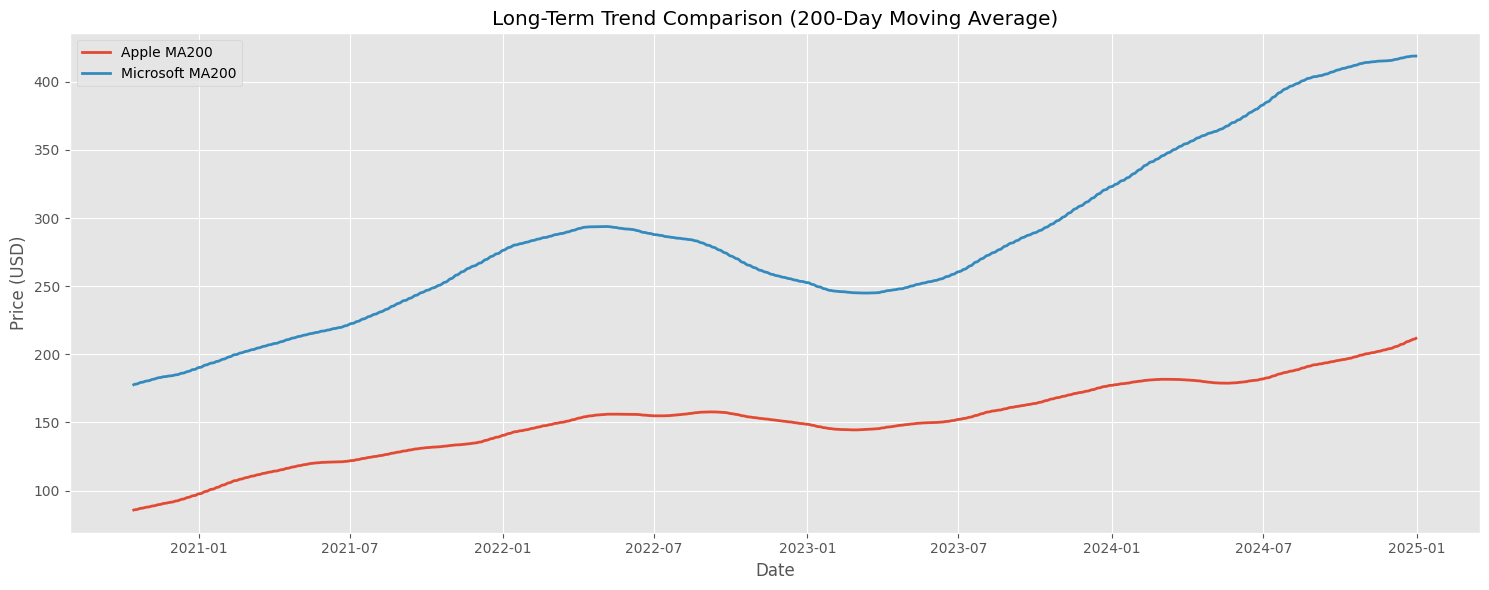

In [28]:
plt.figure(figsize=(15,6))

plt.plot(aapl["MA200"],
         label="Apple MA200",
         linewidth=2)

plt.plot(msft["MA200"],
         label="Microsoft MA200",
         linewidth=2)

plt.title("Long-Term Trend Comparison (200-Day Moving Average)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/moving_averages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- The 20-day moving average closely follows daily price movements and reflects short-term market trends.
- The 200-day moving average changes more gradually and highlights the long-term direction of the stock.
- Apple exhibits larger short-term fluctuations than Microsoft, while both companies show a sustained upward trend over the selected period.
- When the closing price remains above the 200-day moving average, it suggests a strong long-term upward trend during that period.

## 7. Trading Volume Analysis

Trading volume represents the total number of shares exchanged during a trading day.

Analyzing trading volume helps identify periods of increased market activity and provides additional context for price movements. In this section, we compare the trading volumes of Apple and Microsoft throughout the selected time period.

In [29]:
average_volume = pd.DataFrame({
    "Company": ["Apple", "Microsoft"],
    "Average Daily Volume": [
        aapl["Volume"].mean(),
        msft["Volume"].mean()
    ]
})

average_volume

,Company,Average Daily Volume
0,Apple,9.057103e+07
1,Microsoft,2.863777e+07


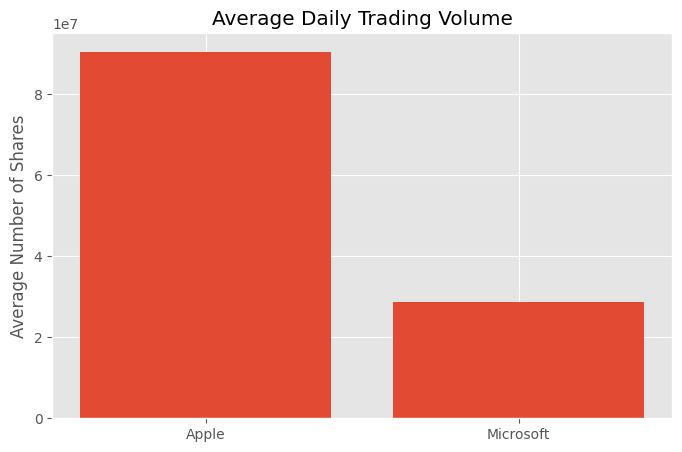

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    average_volume["Company"],
    average_volume["Average Daily Volume"]
)

plt.title("Average Daily Trading Volume")
plt.ylabel("Average Number of Shares")

plt.show()

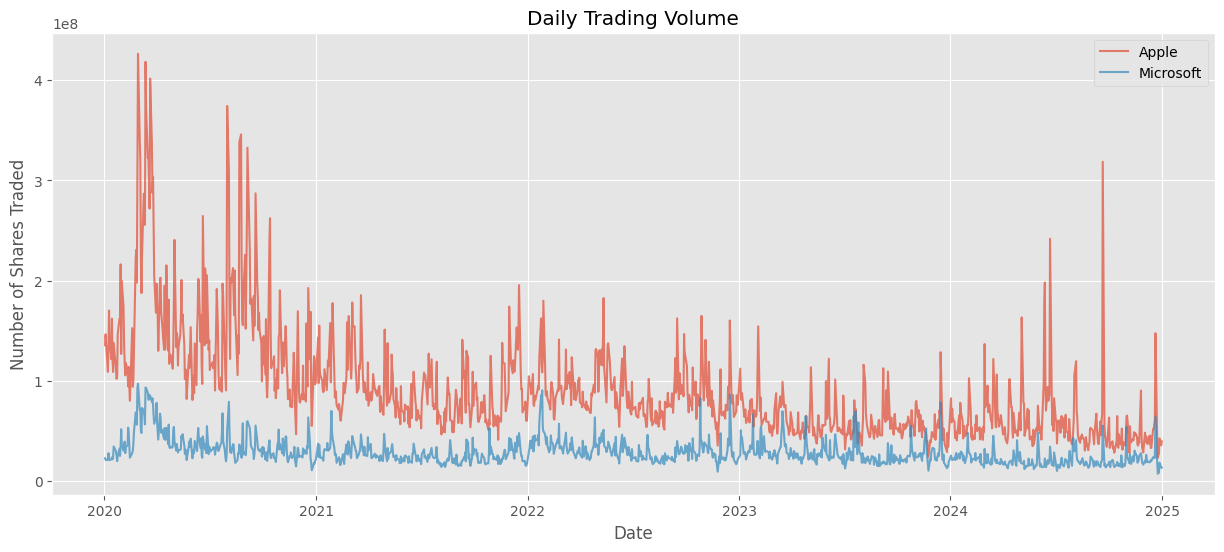

In [31]:
plt.figure(figsize=(15,6))

plt.plot(
    aapl.index,
    aapl["Volume"],
    label="Apple",
    alpha=0.7
)

plt.plot(
    msft.index,
    msft["Volume"],
    label="Microsoft",
    alpha=0.7
)

plt.title("Daily Trading Volume")

plt.xlabel("Date")
plt.ylabel("Number of Shares Traded")

plt.legend()

plt.grid(True)

plt.show()

In [32]:
monthly_volume = pd.DataFrame({
    "Apple": aapl["Volume"].resample("ME").mean(),
    "Microsoft": msft["Volume"].resample("ME").mean()
})

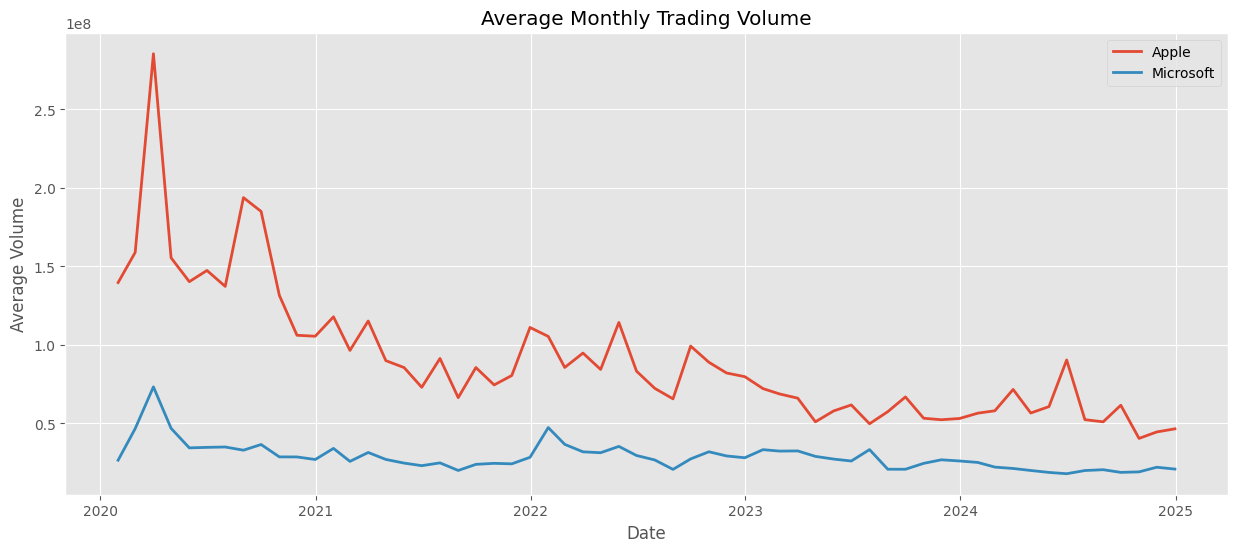

In [33]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_volume.index,
    monthly_volume["Apple"],
    label="Apple",
    linewidth=2
)

plt.plot(
    monthly_volume.index,
    monthly_volume["Microsoft"],
    label="Microsoft",
    linewidth=2
)

plt.title("Average Monthly Trading Volume")

plt.xlabel("Date")
plt.ylabel("Average Volume")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
highest_volume_day = aapl["Volume"].idxmax()

print("Apple Highest Volume Day:", highest_volume_day)
print("Volume:", aapl.loc[highest_volume_day, "Volume"])

Apple Highest Volume Day: 2020-02-28 00:00:00
Volume: 426510000


In [35]:
highest_volume_day = msft["Volume"].idxmax()

print("Microsoft Highest Volume Day:", highest_volume_day)
print("Volume:", msft.loc[highest_volume_day, "Volume"])

Microsoft Highest Volume Day: 2020-02-28 00:00:00
Volume: 97012700


### Observations

- Apple generally records a higher average daily trading volume than Microsoft during the selected period.
- Trading volume fluctuates considerably over time, with noticeable spikes on certain trading days.
- Monthly average trading volume provides a smoother representation of market activity than daily observations.
- High trading volume often coincides with periods of significant market interest or major corporate events.

## 8. Daily Returns Analysis

While stock prices indicate the market value of a company, they do not directly show how much the stock changed from one trading day to the next.

Daily returns measure the percentage change in the closing price between consecutive trading days. This metric is widely used in finance to evaluate performance, compare different stocks, and assess market volatility.

In [36]:
aapl["Daily Return"] = aapl["Close"].pct_change()

msft["Daily Return"] = msft["Close"].pct_change()

In [37]:
aapl[["Close", "Daily Return"]].head(10)

Price,Close,Daily Return
Date,,
2020-01-02,72.333885,NaN
2020-01-03,71.630646,-0.009722
2020-01-06,72.201408,0.007968
2020-01-07,71.861862,-0.004703
2020-01-08,73.017845,0.016086
2020-01-09,74.568802,0.021241
2020-01-10,74.737373,0.002261
2020-01-13,76.334091,0.021364
2020-01-14,75.303337,-0.013503


In [38]:
msft[["Close", "Daily Return"]].head(10)

Price,Close,Daily Return
Date,,
2020-01-02,151.829514,NaN
2020-01-03,149.938980,-0.012452
2020-01-06,150.326553,0.002585
2020-01-07,148.955933,-0.009118
2020-01-08,151.328552,0.015928
2020-01-09,153.219086,0.012493
2020-01-10,152.510147,-0.004627
2020-01-13,154.343979,0.012024
2020-01-14,153.256912,-0.007043


In [39]:
daily_return_summary = pd.DataFrame({
    "Apple": aapl["Daily Return"].describe(),
    "Microsoft": msft["Daily Return"].describe()
})

daily_return_summary

,Apple,Microsoft
count,1257.000000,1257.000000
mean,0.001182,0.000988
std,0.019956,0.019211
min,-0.128647,-0.147390
25%,-0.008425,-0.008176
50%,0.001187,0.001111
75%,0.011989,0.010940
max,0.119808,0.142169


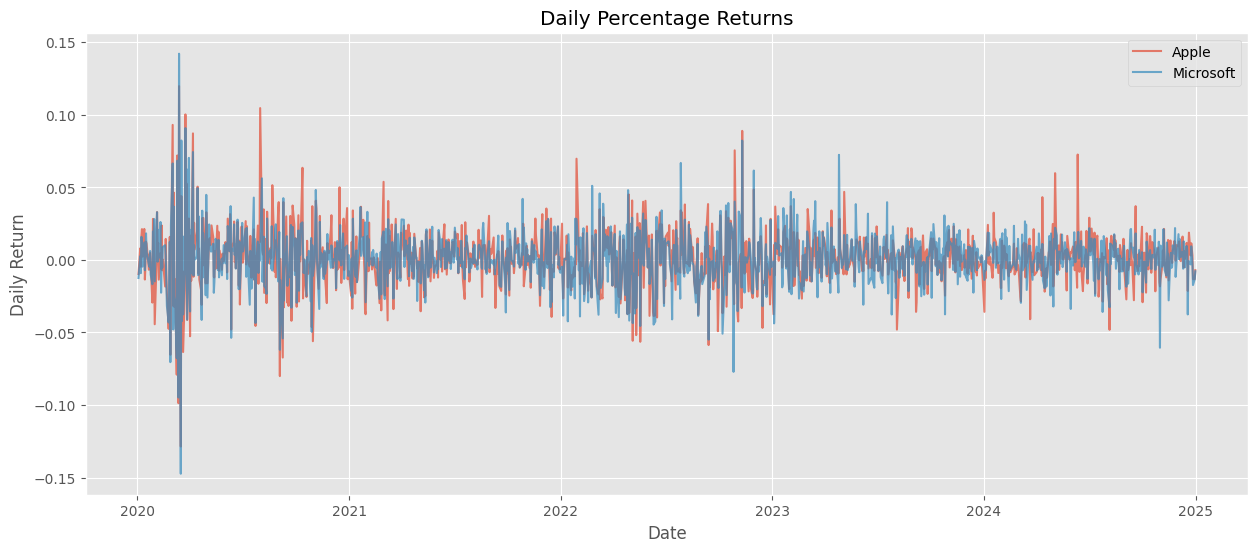

In [40]:
plt.figure(figsize=(15,6))

plt.plot(
    aapl.index,
    aapl["Daily Return"],
    label="Apple",
    alpha=0.7
)

plt.plot(
    msft.index,
    msft["Daily Return"],
    label="Microsoft",
    alpha=0.7
)

plt.title("Daily Percentage Returns")

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.legend()

plt.grid(True)

plt.show()

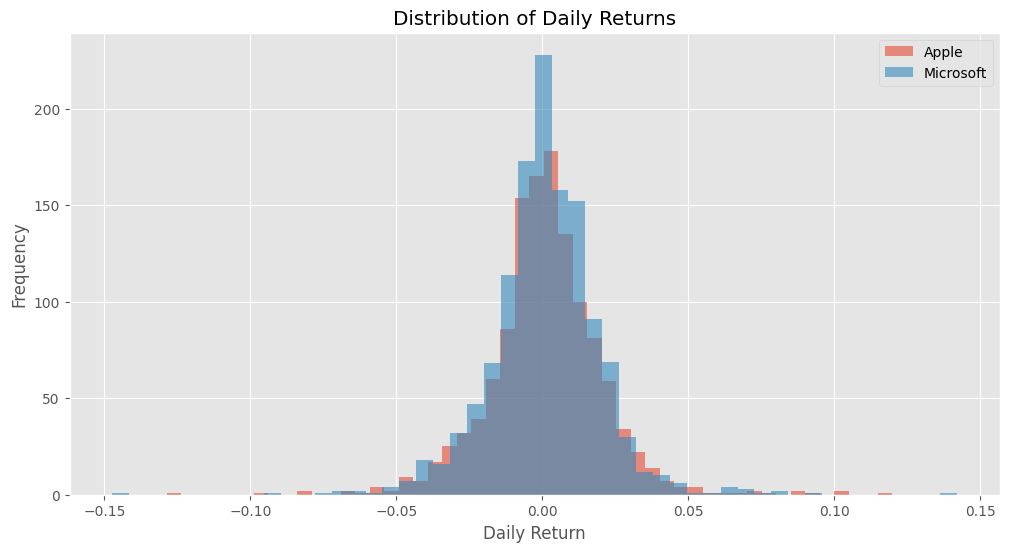

In [41]:
plt.figure(figsize=(12,6))

plt.hist(
    aapl["Daily Return"].dropna(),
    bins=50,
    alpha=0.6,
    label="Apple"
)

plt.hist(
    msft["Daily Return"].dropna(),
    bins=50,
    alpha=0.6,
    label="Microsoft"
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.legend()

plt.show()

In [42]:
print("Apple")

print("Largest Gain")
print(aapl["Daily Return"].max())

print("Largest Loss")
print(aapl["Daily Return"].min())

Apple
Largest Gain
0.11980816637396097
Largest Loss
-0.12864699801576207


In [43]:
print("\nMicrosoft")

print("Largest Gain")
print(msft["Daily Return"].max())

print("Largest Loss")
print(msft["Daily Return"].min())


Microsoft
Largest Gain
0.14216867302508707
Largest Loss
-0.14739011214554287


In [44]:
print("Apple Largest Gain Date:")
print(aapl["Daily Return"].idxmax())

print("\nApple Largest Loss Date:")
print(aapl["Daily Return"].idxmin())

Apple Largest Gain Date:
2020-03-13 00:00:00

Apple Largest Loss Date:
2020-03-16 00:00:00


In [45]:
print("Microsoft Largest Gain Date:")
print(msft["Daily Return"].idxmax())

print("\nMicrosoft Largest Loss Date:")
print(msft["Daily Return"].idxmin())

Microsoft Largest Gain Date:
2020-03-13 00:00:00

Microsoft Largest Loss Date:
2020-03-16 00:00:00


### Observations

- Daily returns fluctuate around zero, indicating alternating gains and losses during the study period.
- Most daily returns are relatively small, while large positive or negative movements occur infrequently.
- The distribution of returns is concentrated near zero with a few extreme values, which is typical of stock market data.
- Comparing the spread of daily returns provides insight into the relative volatility of each stock.

## 9. Cumulative Returns Analysis

Daily returns provide information about short-term price changes, but investors are often more interested in the overall growth of an investment.

Cumulative returns measure the total return achieved over time by compounding daily percentage changes. This analysis illustrates how an initial investment would have grown during the selected period.

In [46]:
aapl["Cumulative Return"] = (
    1 + aapl["Daily Return"]
).cumprod()

msft["Cumulative Return"] = (
    1 + msft["Daily Return"]
).cumprod()

In [47]:
aapl[["Daily Return", "Cumulative Return"]].head(10)

Price,Daily Return,Cumulative Return
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.009722,0.990278
2020-01-06,0.007968,0.998169
2020-01-07,-0.004703,0.993474
2020-01-08,0.016086,1.009456
2020-01-09,0.021241,1.030897
2020-01-10,0.002261,1.033228
2020-01-13,0.021364,1.055302
2020-01-14,-0.013503,1.041052


In [48]:
msft[["Daily Return", "Cumulative Return"]].head(10)

Price,Daily Return,Cumulative Return
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.012452,0.987548
2020-01-06,0.002585,0.990101
2020-01-07,-0.009118,0.981074
2020-01-08,0.015928,0.996701
2020-01-09,0.012493,1.009152
2020-01-10,-0.004627,1.004483
2020-01-13,0.012024,1.016561
2020-01-14,-0.007043,1.009401


In [49]:
initial_investment = 100

aapl["Portfolio Value"] = (
    aapl["Cumulative Return"] * initial_investment
)

msft["Portfolio Value"] = (
    msft["Cumulative Return"] * initial_investment
)

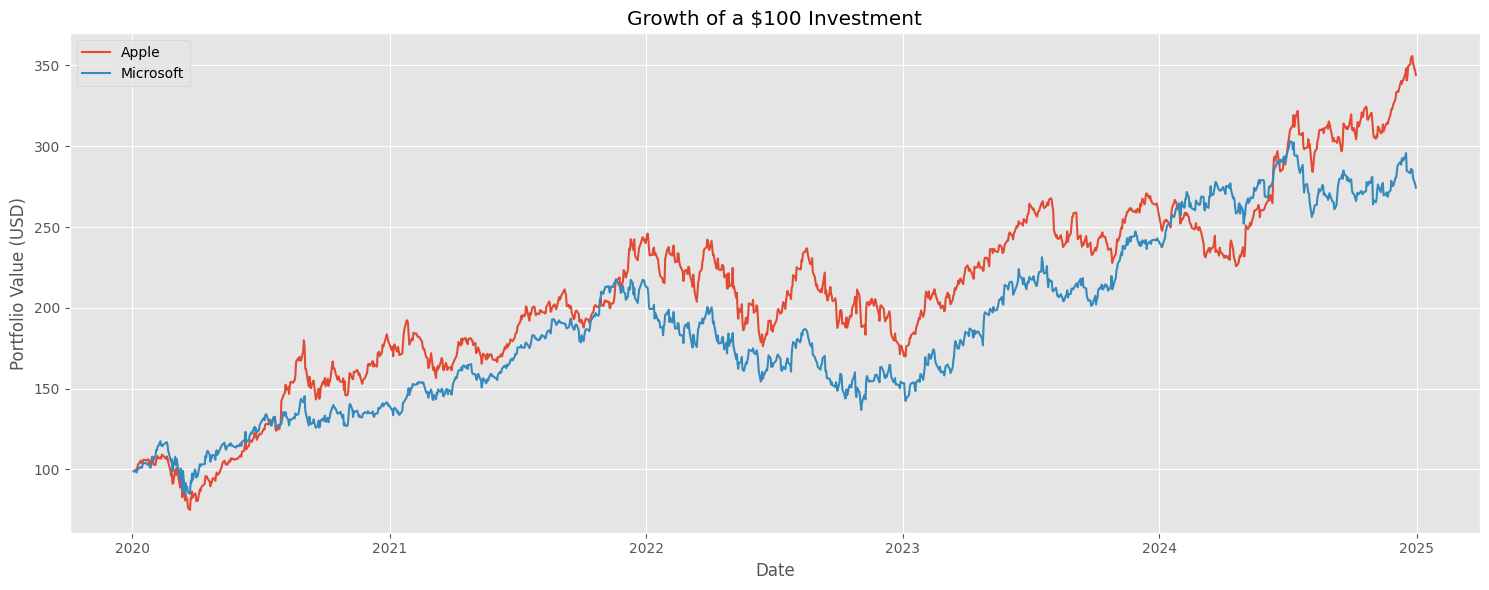

In [50]:
plt.figure(figsize=(15,6))

plt.plot(
    aapl.index,
    aapl["Portfolio Value"],
    label="Apple"
)

plt.plot(
    msft.index,
    msft["Portfolio Value"],
    label="Microsoft"
)

plt.title("Growth of a $100 Investment")

plt.xlabel("Date")

plt.ylabel("Portfolio Value (USD)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/cumulative_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
print("Apple Final Value")

print(f"${aapl['Portfolio Value'].iloc[-1]:.2f}")

print()

print("Microsoft Final Value")

print(f"${msft['Portfolio Value'].iloc[-1]:.2f}")

Apple Final Value
$344.00

Microsoft Final Value
$274.36


In [52]:
apple_return = (
    (aapl["Portfolio Value"].iloc[-1] / initial_investment - 1)
    * 100
)

microsoft_return = (
    (msft["Portfolio Value"].iloc[-1] / initial_investment - 1)
    * 100
)

print(f"Apple Total Return: {apple_return:.2f}%")
print(f"Microsoft Total Return: {microsoft_return:.2f}%")

Apple Total Return: 244.00%
Microsoft Total Return: 174.36%


In [53]:
if apple_return > microsoft_return:
    print("Apple produced the higher overall return.")
elif microsoft_return > apple_return:
    print("Microsoft produced the higher overall return.")
else:
    print("Both investments produced the same return.")

Apple produced the higher overall return.


### Observations

- Both stocks exhibit long-term growth over the selected period, despite experiencing short-term fluctuations.
- The cumulative return curve demonstrates the compounding effect of daily returns over time.
- Simulating a fixed initial investment provides an intuitive way to compare investment performance.
- The stock with the higher final portfolio value generated the stronger overall return during the study period.

## 10. Volatility Analysis

Volatility measures the degree of variation in stock returns over time. Higher volatility indicates larger fluctuations in returns and is generally associated with greater investment risk.

A common approach is to calculate the rolling standard deviation of daily returns, which shows how volatility changes throughout the observation period.

In [54]:
aapl["Volatility"] = (
    aapl["Daily Return"]
    .rolling(window=20)
    .std()
)

msft["Volatility"] = (
    msft["Daily Return"]
    .rolling(window=20)
    .std()
)

In [55]:
aapl[["Daily Return", "Volatility"]].head(30)

Price,Daily Return,Volatility
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.009722,NaN
2020-01-06,0.007968,NaN
2020-01-07,-0.004703,NaN
2020-01-08,0.016086,NaN
2020-01-09,0.021241,NaN
2020-01-10,0.002261,NaN
2020-01-13,0.021364,NaN
2020-01-14,-0.013503,NaN


In [56]:
msft[["Daily Return", "Volatility"]].head(30)

Price,Daily Return,Volatility
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.012452,NaN
2020-01-06,0.002585,NaN
2020-01-07,-0.009118,NaN
2020-01-08,0.015928,NaN
2020-01-09,0.012493,NaN
2020-01-10,-0.004627,NaN
2020-01-13,0.012024,NaN
2020-01-14,-0.007043,NaN


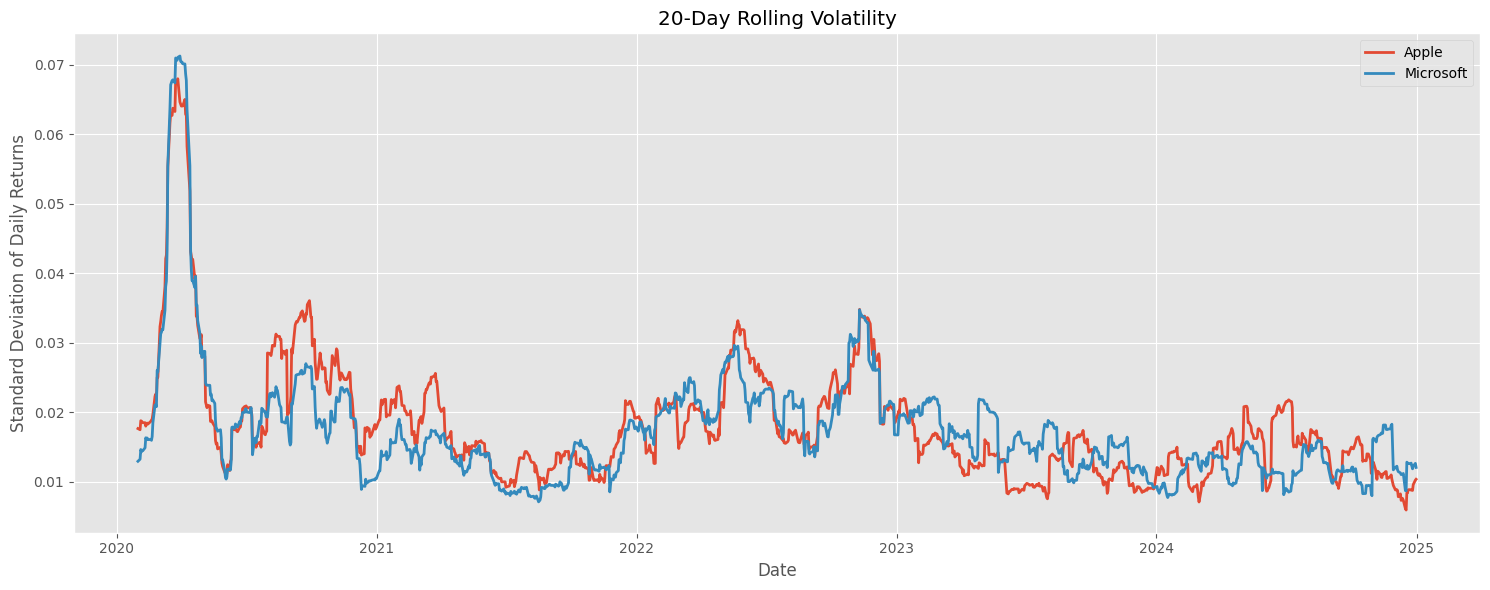

In [57]:
plt.figure(figsize=(15,6))

plt.plot(
    aapl.index,
    aapl["Volatility"],
    label="Apple",
    linewidth=2
)

plt.plot(
    msft.index,
    msft["Volatility"],
    label="Microsoft",
    linewidth=2
)

plt.title("20-Day Rolling Volatility")

plt.xlabel("Date")
plt.ylabel("Standard Deviation of Daily Returns")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
volatility_summary = pd.DataFrame({
    "Company": ["Apple", "Microsoft"],
    "Average Volatility": [
        aapl["Volatility"].mean(),
        msft["Volatility"].mean()
    ]
})

volatility_summary

,Company,Average Volatility
0,Apple,0.018103
1,Microsoft,0.017401


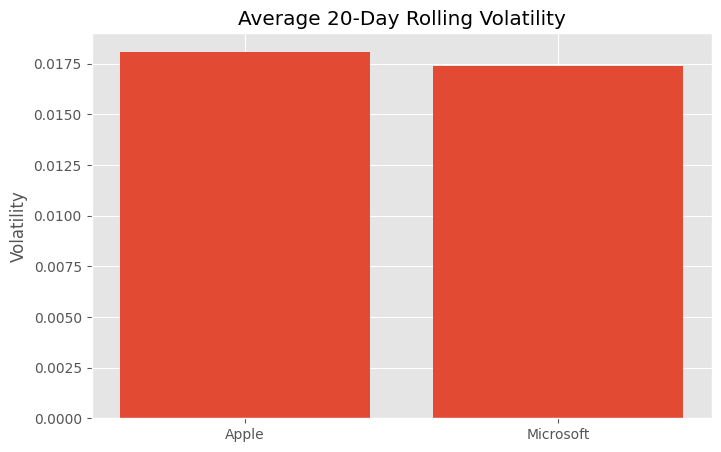

In [59]:
plt.figure(figsize=(8,5))

plt.bar(
    volatility_summary["Company"],
    volatility_summary["Average Volatility"]
)

plt.title("Average 20-Day Rolling Volatility")

plt.ylabel("Volatility")

plt.show()

In [60]:
print("Apple Highest Volatility")

print(aapl["Volatility"].idxmax())

print(aapl["Volatility"].max())

Apple Highest Volatility
2020-03-27 00:00:00
0.06800413946731317


In [61]:
print("Microsoft Highest Volatility")

print(msft["Volatility"].idxmax())

print(msft["Volatility"].max())

Microsoft Highest Volatility
2020-03-30 00:00:00
0.07127442920242476


In [62]:
apple_volatility = aapl["Volatility"].mean()
microsoft_volatility = msft["Volatility"].mean()

if apple_volatility > microsoft_volatility:
    print("Apple was more volatile over the selected period.")
elif microsoft_volatility > apple_volatility:
    print("Microsoft was more volatile over the selected period.")
else:
    print("Both stocks had similar volatility.")

Apple was more volatile over the selected period.


### Observations

- Rolling volatility changes over time, reflecting periods of calm and market uncertainty.
- Higher volatility indicates larger fluctuations in daily returns and therefore greater investment risk.
- Significant spikes in volatility often coincide with major market events or periods of economic uncertainty.
- Comparing the average rolling volatility provides a useful measure of the relative risk of the two stocks.

## 11. Correlation Analysis

Correlation measures the strength and direction of the relationship between two variables.

In financial analysis, correlation between stock returns helps determine whether two assets tend to move together. A strong positive correlation indicates similar price movements, while a low or negative correlation suggests greater diversification potential.

In [63]:
returns = pd.DataFrame({
    "Apple": aapl["Daily Return"],
    "Microsoft": msft["Daily Return"]
})

returns.head()

,Apple,Microsoft
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.009722,-0.012452
2020-01-06,0.007968,0.002585
2020-01-07,-0.004703,-0.009118
2020-01-08,0.016086,0.015928


In [64]:
correlation_matrix = returns.corr()

correlation_matrix

,Apple,Microsoft
Apple,1.000000,0.748327
Microsoft,0.748327,1.000000


In [65]:
correlation = returns["Apple"].corr(
    returns["Microsoft"]
)

print(f"Correlation: {correlation:.3f}")

Correlation: 0.748


In [66]:
if correlation > 0.7:
    print("Strong positive correlation")
elif correlation > 0.3:
    print("Moderate positive correlation")
elif correlation > 0:
    print("Weak positive correlation")
elif correlation == 0:
    print("No correlation")
else:
    print("Negative correlation")

Strong positive correlation


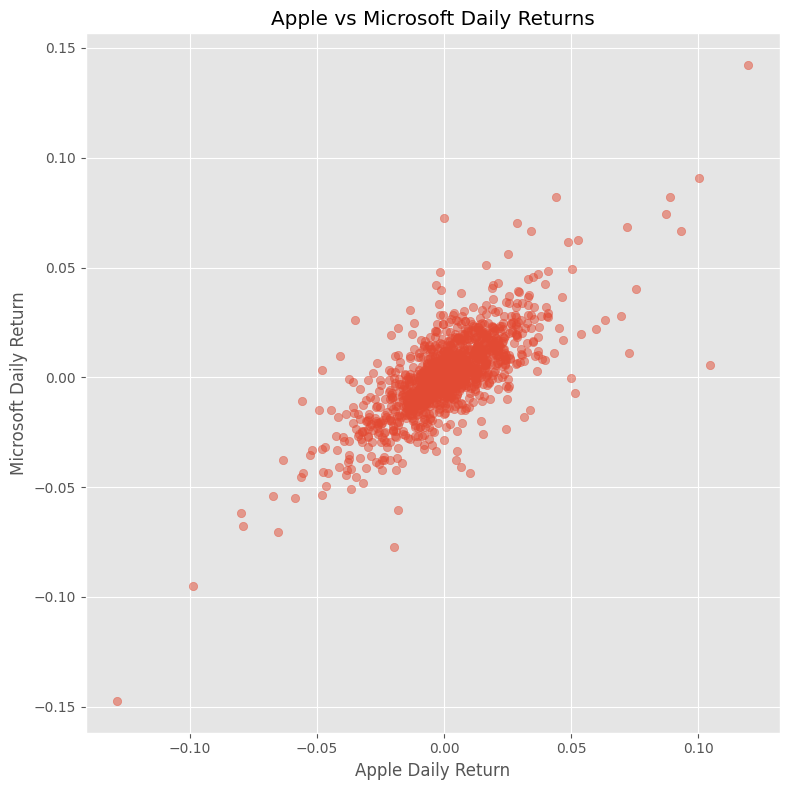

In [67]:
plt.figure(figsize=(8,8))

plt.scatter(
    returns["Apple"],
    returns["Microsoft"],
    alpha=0.5
)

plt.title("Apple vs Microsoft Daily Returns")

plt.xlabel("Apple Daily Return")

plt.ylabel("Microsoft Daily Return")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/correlation_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- Apple and Microsoft exhibit a positive correlation in their daily returns, indicating that they often move in the same direction.
- The scatter plot shows an upward trend, supporting the positive relationship between the two stocks.
- Despite the positive correlation, the points are not perfectly aligned, indicating that each company is also influenced by firm-specific factors.
- Correlation is useful for assessing diversification when constructing investment portfolios.

## 12. Annual Performance Summary

While daily and monthly analyses provide detailed insights into stock behavior, annual performance offers a broader perspective on long-term trends.

This section summarizes the yearly returns of Apple and Microsoft, allowing for a straightforward comparison of their performance across different calendar years.

In [68]:
aapl_yearly = aapl["Close"].resample("YE").last()

msft_yearly = msft["Close"].resample("YE").last()

In [69]:
aapl_annual_return = (
    aapl_yearly.pct_change() * 100
)

msft_annual_return = (
    msft_yearly.pct_change() * 100
)

In [70]:
annual_summary = pd.DataFrame({
    "Apple (%)": aapl_annual_return,
    "Microsoft (%)": msft_annual_return
})

annual_summary

,Apple (%),Microsoft (%)
Date,,
2020-12-31,NaN,NaN
2021-12-31,34.648182,52.476894
2022-12-31,-26.404188,-28.024754
2023-12-31,49.008039,58.191298
2024-12-31,30.705258,12.927311


In [71]:
annual_summary = annual_summary.round(2)

annual_summary

,Apple (%),Microsoft (%)
Date,,
2020-12-31,NaN,NaN
2021-12-31,34.65,52.48
2022-12-31,-26.40,-28.02
2023-12-31,49.01,58.19
2024-12-31,30.71,12.93


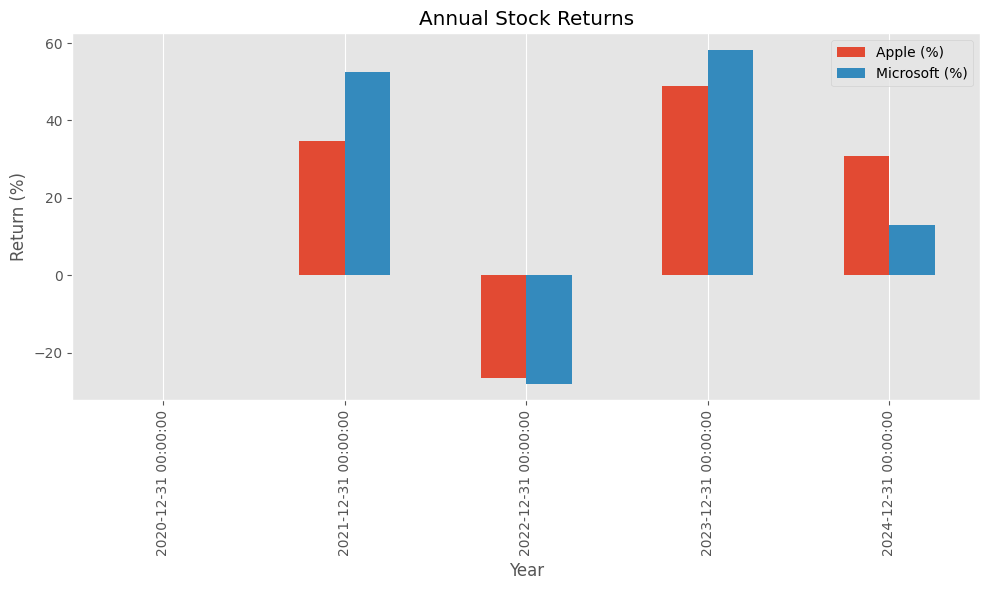

In [72]:
annual_summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Annual Stock Returns")

plt.xlabel("Year")

plt.ylabel("Return (%)")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "images/annual_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
print("Apple Best Year")

print(aapl_annual_return.idxmax())

print(aapl_annual_return.max())

Apple Best Year
2023-12-31 00:00:00
49.00803888983671


In [74]:
print("Microsoft Best Year")

print(msft_annual_return.idxmax())

print(msft_annual_return.max())

Microsoft Best Year
2023-12-31 00:00:00
58.19129827068687


In [75]:
print("Apple Worst Year")

print(aapl_annual_return.idxmin())

print(aapl_annual_return.min())

Apple Worst Year
2022-12-31 00:00:00
-26.404187928524124


In [76]:
print("Microsoft Worst Year")

print(msft_annual_return.idxmin())

print(msft_annual_return.min())

Microsoft Worst Year
2022-12-31 00:00:00
-28.024753946965355


In [77]:
print("Average Annual Return")

print(f"Apple: {aapl_annual_return.mean():.2f}%")

print(f"Microsoft: {msft_annual_return.mean():.2f}%")

Average Annual Return
Apple: 21.99%
Microsoft: 23.89%


### Observations

- Annual returns vary considerably from year to year, reflecting changing market conditions.
- Some years exhibit strong positive growth, while others show negative returns due to broader economic or company-specific factors.
- Comparing annual returns provides a concise overview of long-term performance.
- Annual summaries complement daily and monthly analyses by highlighting broader investment trends.

# 13. Conclusion

This project analyzed the historical stock performance of Apple (AAPL) and Microsoft (MSFT) using Python, Pandas, Matplotlib, and the `yfinance` library. Historical stock prices from January 2020 to January 2025 were collected and analyzed using a range of time series techniques.

The analysis included:

- Exploration and preparation of historical stock data
- Visualization of daily closing prices
- Weekly and monthly time series resampling
- Short-term (20-day) and long-term (200-day) moving average analysis
- Trading volume comparison
- Daily return analysis
- Cumulative return analysis using a simulated investment
- Rolling volatility analysis
- Correlation analysis between stock returns
- Annual performance comparison

### Key Findings

- Both Apple and Microsoft demonstrated positive long-term growth over the selected period despite periods of market volatility.
- Moving averages effectively highlighted short-term fluctuations and long-term trends.
- Daily return and cumulative return analyses provided a clearer understanding of investment performance than stock prices alone.
- Volatility analysis revealed that market risk changes over time and can increase significantly during periods of uncertainty.
- Correlation analysis showed that Apple and Microsoft generally move in the same direction, although each stock also experiences company-specific movements.
- Annual performance summaries made it easier to compare long-term performance across different market conditions.

### Limitations

This project focused on historical market data for only two companies. Historical performance does not guarantee future results, and stock prices are influenced by many external factors such as economic conditions, interest rates, company earnings, and global events.

Overall, this project demonstrates how Python can be used to perform practical financial time series analysis, visualize market trends, and generate meaningful insights from historical stock data.